## Topic: Text Analysis and Word Clouds


### Learning objectives

By the end of the activity, you should be able to:

1. Explain the purpose of each stage of the analysis.
2. Read and discuss Python code rather than simply run it.
3. Select a chart because it answers an analytical question.
4. Interpret numerical and visual output in plain language.
5. Recognise limitations in the analysis.
6. Communicate a conclusion supported by evidence.



## How to work through this activity

Before running each code cell, try to answer three questions:

**1. What is this code trying to achieve?**  
**2. What output do we expect?**  
**3. How will that output help answer the analytical question?**

This turns coding into analytical reasoning rather than a sequence of commands.


### Checkpoint

**Question:** Which libraries are required, and what job does each library perform?

**Purpose:** We first prepare the analytical environment. Students should understand why a library is imported rather than treating imports as boilerplate.

**Before running the cell:** try to predict the output.


In [1]:
# Step 1: Import Necessary Libraries
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import nltk

# Download stopwords from NLTK
nltk.download('stopwords')
from nltk.corpus import stopwords


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/avfrad/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#### Interpreting the output

Use the following structure instead of simply saying *“the chart shows…”*:

1. **Identify** the variables or information represented.
2. **Describe** the strongest visible pattern.
3. **Explain** why that pattern may matter.
4. **Support** the statement with visible or numerical evidence.
5. **Limit** the conclusion: what does the chart not prove?

**Discussion question:** Would another chart communicate the same information more clearly?


### Checkpoint

**Question:** What data are we loading, and what does one row represent?

**Purpose:** Before analysing a dataset, we need to understand its structure and context.

**Before running the cell:** try to predict the output.


In [2]:
# Step 2: Load the Diseases and Symptoms Dataset
# Assuming the dataset is in a CSV file named 'diseases_symptoms.csv'
# The dataset should have a column named 'Symptom_Description' or similar.
# For example, you might use 'https://people.dbmi.columbia.edu/~friedma/Projects/DiseaseSymptomKB/index.html' dataset.

#df1 = pd.read_csv('Symptom2Disease.csv')
df2 = pd.read_csv('Symptom-severity.csv')

# Display the first few rows of the dataset
#df1.head()
df2.head()


,Symptom,weight
0,itching,1
1,skin_rash,3
2,nodal_skin_eruptions,4
3,continuous_sneezing,4
4,shivering,5


### Checkpoint

**Question:** What does this step contribute to the analysis?

**Purpose:** Connect every line of code to the analytical objective.

**Before running the cell:** try to predict the output.


In [3]:
# Step 3: Data Preprocessing
# Combine all the symptom descriptions into a single string
# Replace 'Symptom_Description' with the actual column name in your dataset
text = " ".join(text for text in df2['Symptom'])

# Define stopwords
custom_stopwords = set(stopwords.words('english')).union(STOPWORDS)

# Add more stopwords if necessary
# custom_stopwords.update(['disease', 'symptom', 'patient', 'treatment'])  # Example of adding more stopwords


### Checkpoint

**Question:** What question is this visualisation designed to answer?

**Purpose:** A useful chart should communicate an analytical message, not merely decorate the notebook.

**Before running the cell:** Try to predict the output.


In [4]:
# Step 4: Generate the Word Cloud
wordcloud = WordCloud(stopwords=custom_stopwords, background_color='white', max_words=100, width=800, height=400).generate(text)


#### Interpreting the output

Use the following structure instead of simply saying *“the chart shows…”*:

1. **Identify** the variables or information represented.
2. **Describe** the strongest visible pattern.
3. **Explain** why that pattern may matter.
4. **Support** the statement with visible or numerical evidence.
5. **Limit** the conclusion: what does the chart not prove?

**Discussion question:** Would another chart communicate the same information more clearly?


### Checkpoint

**Question:** What question is this visualisation designed to answer?

**Purpose:** A useful chart should communicate an analytical message, not merely decorate the notebook.

**Before running the cell:** try to predict the output.


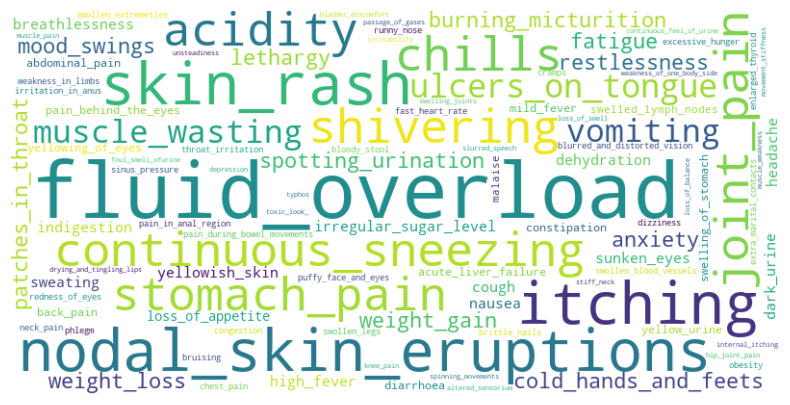

In [5]:
# Step 5: Plot the Word Cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off axis
plt.show()


#### Interpreting the output

Use the following structure instead of simply saying *“the chart shows…”*:

1. **Identify** the variables or information represented.
2. **Describe** the strongest visible pattern.
3. **Explain** why that pattern may matter.
4. **Support** the statement with visible or numerical evidence.
5. **Limit** the conclusion: what does the chart not prove?

**Discussion question:** Would another chart communicate the same information more clearly?


## Making the visualisation more informative

A good analytical visualisation needs:

- a descriptive title;
- meaningful axis labels;
- readable categories;
- appropriate chart type;
- minimal unnecessary decoration;
- an interpretation immediately after the chart.



In [6]:
# Find DataFrames produced by the original activity.
dataframes = {
    name: obj for name, obj in globals().items()
    if isinstance(obj, pd.DataFrame)
}

if dataframes:
    df_teaching = max(dataframes.values(), key=len).copy()

    print(f"Dataset size: {df_teaching.shape[0]:,} rows × {df_teaching.shape[1]} columns")
    display(df_teaching.head())
else:
    print("No DataFrame is currently available. Run the earlier activity cells first.")


Dataset size: 133 rows × 2 columns


,Symptom,weight
0,itching,1
1,skin_rash,3
2,nodal_skin_eruptions,4
3,continuous_sneezing,4
4,shivering,5


### A better first summary

Before producing a complex visualisation, you should understand the dataset itself.

- Which columns are numerical?
- Which are categorical or textual?
- Are values missing?
- Are some categories much more common than others?
- Which variable is the main focus of the activity?


In [7]:
if 'df_teaching' in globals():
    summary = pd.DataFrame({
        "Data type": df_teaching.dtypes.astype(str),
        "Missing": df_teaching.isna().sum(),
        "Unique values": df_teaching.nunique(dropna=True)
    })

    summary["Missing (%)"] = (
        summary["Missing"] / len(df_teaching) * 100
    ).round(2)

    display(summary)


,Data type,Missing,Unique values,Missing (%)
Symptom,str,0,132,0.0
weight,int64,0,7,0.0


## Interpretation framework

Compare these two responses:

**Description:**  
*“Category A has the tallest bar.”*

**Interpretation:**  
*“Category A contains the largest number of observations in this dataset, suggesting that it is more prevalent in the collected sample. However, this does not automatically mean it is more prevalent in the wider population.”*

The second answer is stronger because it includes:

**evidence + meaning + limitation**.


## Critical-thinking questions

1. What is the main analytical question in Activity 4?
2. Which code cell is essential to answering that question?
3. Which step is data preparation rather than analysis?
4. What is the strongest pattern in the output?
5. What evidence supports that interpretation?
6. Is the sample necessarily representative of a wider population?
7. Could preprocessing choices change the result?
8. What additional analysis would strengthen the conclusion?


## Activity conclusion

A strong conclusion should contain four elements:

> **Finding → Evidence → Interpretation → Limitation**

Example structure:

> “The analysis indicates **[main finding]**. This is supported by **[chart/statistic/output]**. One possible interpretation is **[meaning]**. However, **[limitation]** means that we should avoid making a stronger conclusion without additional evidence.”

### Exit ticket

Before finishing, you should be able to answer:

- What did we analyse?
- Why did we perform the preprocessing?
- Why was the chosen visualisation appropriate?
- What is the most important result?
- What can we **not** conclude from the result?
- What would be the logical next analytical step?

The goal is not simply to produce Python output. The goal is to turn that output into a defensible analytical explanation.
